In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

Create a dataset of at least 200 employees with:

emp_id, department, experience_years, salary, performance_score

Using Pandas:
Generate department-wise salary and performance summaries.

Categorize employees into salary bands.

Using NumPy:
Normalize numerical features.

Analyze correlation between salary and performance.

Using a visualization library:

Show salary distribution by department.

Visualize experience vs salary relationship.


In [3]:
data=[]
fake=Faker()
dept=["HR","Sales","IT","Marketting","Finance"]
for i in range(200):
    data.append({
        "emp_id":fake.uuid4(),
        "department":random.choice(dept),
        "experience_years":fake.random_int(min=0,max=25),
        "salary":fake.random_int(min=25000, max=75000),
        "performance_score":fake.random_int(min=1,max=10)
    })
df=pd.DataFrame(data)
print(df.head(10))


                                 emp_id  department  experience_years  salary  \
0  e90af3d6-6743-4944-884f-ce4d2ab6cf18       Sales                17   54586   
1  2b2fc0ba-3fef-4080-a04a-b4286093ae2c          IT                10   67485   
2  d99023a1-7a20-43fa-8020-2fa05e9e1582          HR                 1   59638   
3  42a6cb98-caff-4e90-837e-94f60a950863  Marketting                14   29883   
4  56373880-f64d-4be8-9d34-34942b6cbd76       Sales                18   56986   
5  c1ce45dd-b460-4f5e-bf08-e0510aee8ec3       Sales                18   36836   
6  573d5dd6-4070-4509-963a-ce34446ac6c6  Marketting                13   35991   
7  ef8c46e5-ac03-4e64-b755-e0e26e3e7f42     Finance                12   28623   
8  f244be69-5b07-42e9-8697-6ab8356fc00f  Marketting                25   62630   
9  09cfeb43-c24c-4f6f-aacf-2f58f8d6cde2          HR                12   45871   

   performance_score  
0                 10  
1                  8  
2                  4  
3               



Using Pandas:
Generate department-wise salary and performance summaries.


In [4]:
dept_sum=df.groupby("department").agg(
    total_salary=("salary","sum"),
    avg_sal=("salary","mean"),
    max_sal=("salary","max"),
    min_sal=("salary","min"),
    avg_performance=("performance_score","mean"),
    min_performance=("performance_score","min"),
    max_performance=("performance_score","max"),
    emp_count=("emp_id","count")
).reset_index()
print(dept_sum)

   department  total_salary       avg_sal  max_sal  min_sal  avg_performance  \
0     Finance       1702966  48656.171429    72964    27296         6.028571   
1          HR       1688599  46905.527778    73182    25622         6.611111   
2          IT       2118416  52960.400000    74034    26715         5.300000   
3  Marketting       2069817  50483.341463    74608    25645         5.878049   
4       Sales       2455270  51151.458333    74523    26349         5.458333   

   min_performance  max_performance  emp_count  
0                1               10         35  
1                1               10         36  
2                1               10         40  
3                1               10         41  
4                1               10         48  


Categorize employees into salary bands.

In [5]:
bands=[25000,35000,45000,55000,65000,75000]
labels=["Very low","low","medium","High","very high"]
df["salary_band"]=pd.cut(df["salary"],bins=bands,labels=labels)
print(df.head(10))
# print(df["salary_band"].value_counts())

                                 emp_id  department  experience_years  salary  \
0  e90af3d6-6743-4944-884f-ce4d2ab6cf18       Sales                17   54586   
1  2b2fc0ba-3fef-4080-a04a-b4286093ae2c          IT                10   67485   
2  d99023a1-7a20-43fa-8020-2fa05e9e1582          HR                 1   59638   
3  42a6cb98-caff-4e90-837e-94f60a950863  Marketting                14   29883   
4  56373880-f64d-4be8-9d34-34942b6cbd76       Sales                18   56986   
5  c1ce45dd-b460-4f5e-bf08-e0510aee8ec3       Sales                18   36836   
6  573d5dd6-4070-4509-963a-ce34446ac6c6  Marketting                13   35991   
7  ef8c46e5-ac03-4e64-b755-e0e26e3e7f42     Finance                12   28623   
8  f244be69-5b07-42e9-8697-6ab8356fc00f  Marketting                25   62630   
9  09cfeb43-c24c-4f6f-aacf-2f58f8d6cde2          HR                12   45871   

   performance_score salary_band  
0                 10      medium  
1                  8   very high  
2  

Using NumPy:
Normalize numerical features.(z-Score or min max normalisation)


In [6]:
# use zscore for getting outliers

# df["experience_years"]=(df["experience_years"]-np.mean(df["experience_years"]))/np.std(df["experience_years"])
# df["salary"]=(df["salary"]-np.mean(df["salary"]))/np.std(df["salary"])
# df["performance_score"]=(df["performance_score"]-np.mean(df["performance_score"]))-np.std(df["performance_score"])

# using mean max for getting output in 0 or 1
df["experience_years"]=(df["experience_years"]-np.min(df["experience_years"]))/(np.max(df["experience_years"])-np.min(df["experience_years"]))
df["salary"]=(df["salary"]-np.min(df["salary"]))/(np.max(df["salary"])-np.min(df["salary"]))
df["performance_score"]=(df["performance_score"]-np.min(df["performance_score"]))/(np.max(df["performance_score"])-np.min(df["performance_score"]))

print(df.head(10))

                                 emp_id  department  experience_years  salary  \
0  e90af3d6-6743-4944-884f-ce4d2ab6cf18       Sales                17   54586   
1  2b2fc0ba-3fef-4080-a04a-b4286093ae2c          IT                10   67485   
2  d99023a1-7a20-43fa-8020-2fa05e9e1582          HR                 1   59638   
3  42a6cb98-caff-4e90-837e-94f60a950863  Marketting                14   29883   
4  56373880-f64d-4be8-9d34-34942b6cbd76       Sales                18   56986   
5  c1ce45dd-b460-4f5e-bf08-e0510aee8ec3       Sales                18   36836   
6  573d5dd6-4070-4509-963a-ce34446ac6c6  Marketting                13   35991   
7  ef8c46e5-ac03-4e64-b755-e0e26e3e7f42     Finance                12   28623   
8  f244be69-5b07-42e9-8697-6ab8356fc00f  Marketting                25   62630   
9  09cfeb43-c24c-4f6f-aacf-2f58f8d6cde2          HR                12   45871   

   performance_score salary_band  
0                 10      medium  
1                  8   very high  
2  

Analyze correlation between salary and performance.

In [7]:
# corr=0.3 to 0.5 moderate relationship 
# corr=0.5 to 0.7 strong relationship
# corr=>0.7 very strong
# corr =0.1 to 0.3 weak relations
# corr==0 to 0.1 no relations

corr=df["salary"].corr(df["performance_score"])
print("Correlation is: ",corr)
# as data is generated random there is not relationship in these

Correlation is:  0.033452529403776674


Using a visualization library:
Show salary distribution by department.

C:\Users\shrey\AppData\Local\Temp\ipykernel_11204\116690080.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(salary_data,labels=depart)


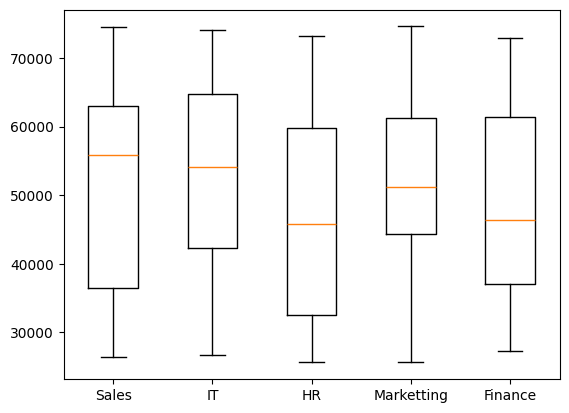

In [8]:
depart=df["department"].unique()
salary_data=[df[df["department"]==dept]["salary"] for dept in depart]
plt.boxplot(salary_data,labels=depart)
plt.show()

Visualize experience vs salary relationship.


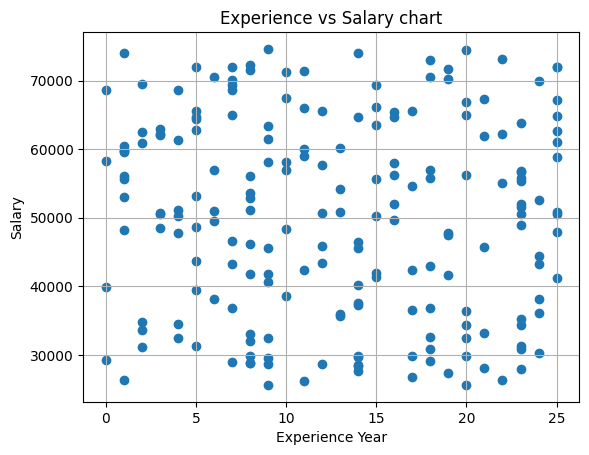

In [9]:
exp=df["experience_years"]
sal=df["salary"]
plt.scatter(exp,sal)
plt.grid()
plt.xlabel("Experience Year")
plt.ylabel("Salary")
plt.title("Experience vs Salary chart")
plt.show()